In [1]:
!pip install openpyxl
!pip install pandas
!pip install numpy
!pip install pathlib
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install numpy
!pip install brokenaxes

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Defaulting to user insta

In [2]:

plot_output_path = "/Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb"
input_path = "/Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb.xlsx"
output_file = "/Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb/86_siRNA_comb_results.xlsx"

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

def detect_outliers(df, threshold=1.5):
    """
    Detect outliers in CT values for each Sample Name + Target Name combination.
    
    Args:
        df (pd.DataFrame): Input dataframe with columns Sample Name, Target Name, CT
        threshold (float): Maximum allowed difference from other values in the same group
    
    Returns:
        set: Set of (Sample Name, Target Name) tuples that contain outliers
    """
    print(f"Detecting outliers with threshold ±{threshold}...")
    
    outlier_combinations = set()
    grouped = df.groupby(['Sample Name', 'Target Name'])
    
    for (sample_name, target_name), group in grouped:
        ct_values = group['CT'].values
        
        if len(ct_values) <= 1:
            continue
        
        has_outlier = False
        for i, ct_val in enumerate(ct_values):
            other_values = np.concatenate([ct_values[:i], ct_values[i+1:]])
            min_diff = np.min(np.abs(other_values - ct_val))
            
            if min_diff > threshold:
                has_outlier = True
                print(f"OUTLIER DETECTED: {sample_name} {target_name} - Value {ct_val:.3f} differs by {min_diff:.3f}")
                break
        
        if has_outlier:
            outlier_combinations.add((sample_name, target_name))
            print(f"  -> Excluding combination: {sample_name} + {target_name}")
    
    print(f"Found {len(outlier_combinations)} combinations with outliers")
    return outlier_combinations

def save_step_result(df, base_output_path, step_name, step_number):
    """
    Save intermediate results for each processing step.
    """
    base_dir = os.path.dirname(base_output_path)
    if base_dir:
        os.makedirs(base_dir, exist_ok=True)
    
    base_name = os.path.splitext(os.path.basename(base_output_path))[0]
    step_filename = f"{base_name}_step{step_number}_{step_name}.xlsx"
    step_path = os.path.join(base_dir, step_filename)
    
    if isinstance(df, dict):
        with pd.ExcelWriter(step_path) as writer:
            for sheet_name, data in df.items():
                data.to_excel(writer, sheet_name=sheet_name)
    else:
        df.to_excel(step_path)
    
    print(f"  Saved step {step_number} ({step_name}) to: {step_path}")

def process_qpcr_data_with_errors(input_file, output_file=None, outlier_threshold=1.5, neg_control=""):
    """
    Process qPCR data through the complete normalization pipeline with outlier detection.
    
    Args:
        input_file (str): Path to input Excel/CSV file with columns: Sample Name, Target Name, CT
        output_file (str, optional): Path for output file. If None, saves as 'processed_qpcr_data.xlsx'
        outlier_threshold (float): Threshold for outlier detection (default: 1.5)
        neg_control (str): Name of negative control sample for normalization
    
    Returns:
        tuple: (final_df, error_df, ratio_df) - Final processed data, standard errors, and individual normalized data points
    """
    
    print("Step 1: Reading input data...")
    if str(input_file).endswith('.xlsx'):
        df = pd.read_excel(input_file)
    else:
        df = pd.read_csv(input_file, sep='\t')
    
    df['Sample Name'] = df['Sample Name'].astype(str)
    df['Target Name'] = df['Target Name'].astype(str)
    print(f"Loaded {len(df)} rows of data")
    
    if output_file is None:
        output_file = 'processed_qpcr_data.xlsx'
    
    save_step_result(df, output_file, "raw_data", 1)
    
    valid_df = df
    print(f"Processing {len(valid_df)} rows")
    
    print("\nStep 2: Calculating cDNA values...")
    valid_df['cDNA'] = 10**10 / (2**valid_df['CT'])
    save_step_result(valid_df[['Sample Name', 'Target Name', 'CT', 'cDNA']], output_file, "cDNA_calculation", 2)
    
    print("Step 3: Reshaping data...")
    valid_df['replicate'] = valid_df.groupby(['Sample Name', 'Target Name']).cumcount() + 1
    pivot_df = valid_df.pivot_table(
        index=['Target Name', 'replicate'], 
        columns='Sample Name', 
        values='cDNA', 
        aggfunc='first'
    )
    save_step_result(pivot_df, output_file, "pivoted_data", 3)
    
    print("Step 4: Calculating GAPDH averages...")
    if 'GAPDH' not in pivot_df.index.get_level_values('Target Name'):
        raise ValueError("GAPDH not found in the data. Cannot proceed with normalization.")
    
    gapdh_data = pivot_df.loc['GAPDH']
    gapdh_avg = gapdh_data.mean()
    
    gapdh_results = {
        'gapdh_raw_data': gapdh_data,
        'gapdh_averages': pd.DataFrame([gapdh_avg], index=['GAPDH_Average'])
    }
    save_step_result(gapdh_results, output_file, "GAPDH_averages", 4)
    
    print("Step 5: Normalizing by GAPDH...")
    normalized_df = pivot_df.copy()
    
    for sample in pivot_df.columns:
        if sample in gapdh_avg.index and not pd.isna(gapdh_avg[sample]):
            normalized_df[sample] = (pivot_df[sample] * 10000) / gapdh_avg[sample]
        else:
            print(f"Warning: No valid GAPDH data for sample {sample}")
            normalized_df[sample] = np.nan
    
    save_step_result(normalized_df, output_file, "GAPDH_normalized", 5)
    
    print("Step 6: Calculating negative control averages...")
    if neg_control not in normalized_df.columns:
        print("Warning: Negative control sample not found")
        target_neg_control_avg = pd.Series(dtype=float)
    else:
        target_neg_control_avg = normalized_df[neg_control].groupby('Target Name').mean()
    
    pc3_results = {
        'neg_control_data': normalized_df[[neg_control]] if neg_control in normalized_df.columns else pd.DataFrame(),
        'neg_control_averages': pd.DataFrame(target_neg_control_avg, columns=['neg_control_Average'])
    }
    save_step_result(pc3_results, output_file, neg_control + "_averages", 6)
    
    print("Step 7: Normalizing by negative control averages...")
    ratio_df = normalized_df.copy()
    
    for target in target_neg_control_avg.index:
        if not pd.isna(target_neg_control_avg[target]):
            target_mask = ratio_df.index.get_level_values('Target Name') == target
            ratio_df.loc[target_mask] = ratio_df.loc[target_mask] / target_neg_control_avg[target]
        else:
            print(f"Warning: No valid negative control data for target {target}")
            target_mask = ratio_df.index.get_level_values('Target Name') == target
            ratio_df.loc[target_mask] = np.nan
    
    save_step_result(ratio_df, output_file, "neg_control_normalized", 7)
    
    print("Step 8: Aggregating replicates and calculating errors...")
    final_ratio_df = ratio_df.drop('GAPDH', level='Target Name', errors='ignore')
    
    final_df = final_ratio_df.groupby('Target Name').mean()
    error_df = final_ratio_df.groupby('Target Name').sem()
    
    final_df = final_df.dropna(axis=0, how='all').dropna(axis=1, how='all')
    error_df = error_df.dropna(axis=0, how='all').dropna(axis=1, how='all')
    error_df = error_df.reindex(final_df.index, columns=final_df.columns)
    error_df = error_df.fillna(0)
    
    final_df = final_df.round(8)
    error_df = error_df.round(8)
    
    aggregated_results = {
        'means': final_df,
        'standard_errors': error_df
    }
    save_step_result(aggregated_results, output_file, "aggregated", 8)
    
    print("Step 8.5: Reordering columns...")
    if len(final_df.columns) >= 8:
        columns = list(final_df.columns)
        reordered_first_8 = [columns[1], columns[5], columns[2], columns[6], 
                            columns[3], columns[7], columns[0], columns[4]]
        remaining_columns = columns[8:]
        new_column_order = reordered_first_8 + remaining_columns
        
        final_df = final_df[new_column_order]
        error_df = error_df[new_column_order]
        ratio_df = ratio_df[new_column_order]
    
    reordered_results = {
        'means_reordered': final_df,
        'standard_errors_reordered': error_df
    }
    save_step_result(reordered_results, output_file, "reordered", "8.5")
    
    print("Step 9: Saving final results...")
    if str(output_file).endswith('.xlsx'):
        with pd.ExcelWriter(output_file) as writer:
            final_df.to_excel(writer, sheet_name='Means')
            error_df.to_excel(writer, sheet_name='Standard_Errors')
    else:
        final_df.to_csv(output_file, sep='\t')
        error_file = output_file.replace('.csv', '_errors.csv')
        error_df.to_csv(error_file, sep='\t')
    
    print(f"Processing complete. Results saved to: {output_file}")
    print(f"Final data shape: {final_df.shape}")
    
    return final_df, error_df, ratio_df

def validate_input_data(input_file, neg_control=""):
    """
    Validate that the input file has the expected format.
    """
    try:
        if str(input_file).endswith('.xlsx'):
            df = pd.read_excel(input_file)
        else:
            df = pd.read_csv(input_file, sep='\t')
        
        df['Sample Name'] = df['Sample Name'].astype(str)
        df['Target Name'] = df['Target Name'].astype(str)
        
        required_columns = ['Sample Name', 'Target Name', 'CT']
        missing_columns = [col for col in required_columns if col not in df.columns]
        
        if missing_columns:
            print(f"ERROR: Missing required columns: {missing_columns}")
            return False
        
        if 'GAPDH' not in df['Target Name'].values:
            print("WARNING: GAPDH not found in Target Name column.")
            return False
        
        if neg_control and neg_control not in df['Sample Name'].values:
            print(f"WARNING: Negative control sample '{neg_control}' not found.")
            return False
        
        print("Input validation passed!")
        print(f"Found {df['Sample Name'].nunique()} unique samples")
        print(f"Found {df['Target Name'].nunique()} unique targets")
        
        return True
        
    except Exception as e:
        print(f"ERROR reading file: {e}")
        return False

In [4]:
# if __name__ == "__main__":
#     # Replace with your input file path
#     input_file = input_path  # or "your_qpcr_data.csv"
    
#     # Validate input first
#     if validate_input_data(input_file):
#         # Process the data
#         result = process_qpcr_data(input_file, excel_output_path)
        
#         # Display summary
#         print("\n" + "="*50)
#         print("PROCESSING COMPLETE")
#         print("="*50)
#         print(f"Input file: {input_file}")
#         print(f"Output file: final_results.xlsx")
#         print(f"Final data dimensions: {result.shape}")
#     else:
#         print("Please fix input data issues before proceeding.")

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle
import scipy.stats as stats

def calculate_significance_tests(individual_df, neg_control_sample="1892", alpha_levels=[0.001, 0.01, 0.05]):
    """
    Perform t-tests comparing each sample against the negative control for each target.
    Uses both one-tailed tests (greater and less) and takes the smaller p-value.
    
    Args:
        individual_df (pd.DataFrame): Individual data points from step 7 (with MultiIndex)
        neg_control_sample (str): Name of the negative control sample
        alpha_levels (list): Significance levels for *, **, *** (default: [0.001, 0.01, 0.05])
    
    Returns:
        pd.DataFrame: P-values and significance symbols for each target-sample combination
    """
    print(f"Calculating significance tests using {neg_control_sample} as negative control...")
    
    significance_results = {}
    targets = individual_df.index.get_level_values('Target Name').unique()
    targets = [t for t in targets if t != 'GAPDH']
    samples = [col for col in individual_df.columns if col != neg_control_sample]
    
    print(f"Testing {len(targets)} targets across {len(samples)} samples")
    
    for target in targets:
        target_data = individual_df.loc[individual_df.index.get_level_values('Target Name') == target]
        
        if neg_control_sample not in target_data.columns:
            print(f"Warning: {neg_control_sample} not found for target {target}")
            continue
            
        control_values = target_data[neg_control_sample].dropna()
        
        if len(control_values) < 2:
            print(f"Warning: Not enough control values for {target} (n={len(control_values)})")
            continue
        
        target_results = {}
        
        for sample in samples:
            if sample in target_data.columns:
                sample_values = target_data[sample].dropna()
                
                if len(sample_values) < 2:
                    target_results[sample] = {'p_value': np.nan, 'significance': 'ns'}
                    continue
                
                try:
                    # Perform both one-tailed t-tests and take the smaller p-value
                    t_stat_greater, p_value_greater = stats.ttest_ind(sample_values, control_values, 
                                                                    equal_var=False, alternative='greater')
                    t_stat_less, p_value_less = stats.ttest_ind(sample_values, control_values, 
                                                               equal_var=False, alternative='less')
                    
                    if p_value_greater <= p_value_less:
                        p_value = p_value_greater
                        t_stat = t_stat_greater
                    else:
                        p_value = p_value_less
                        t_stat = t_stat_less
                    
                    # Determine significance level
                    if p_value < alpha_levels[0]:
                        sig_symbol = '***'
                    elif p_value < alpha_levels[1]:
                        sig_symbol = '**'
                    elif p_value < alpha_levels[2]:
                        sig_symbol = '*'
                    else:
                        sig_symbol = 'ns'
                    
                    target_results[sample] = {
                        'p_value': p_value,
                        'significance': sig_symbol,
                        't_statistic': t_stat,
                        'n_sample': len(sample_values),
                        'n_control': len(control_values)
                    }
                    
                except Exception as e:
                    print(f"Error calculating t-test for {target}-{sample}: {e}")
                    target_results[sample] = {'p_value': np.nan, 'significance': 'ns'}
        
        significance_results[target] = target_results
    
    # Convert to DataFrame format
    sig_df = pd.DataFrame.from_dict({
        (target, sample): results['significance'] 
        for target, target_data in significance_results.items()
        for sample, results in target_data.items()
    }, orient='index')
    
    if not sig_df.empty:
        sig_df.index = pd.MultiIndex.from_tuples(sig_df.index, names=['Target', 'Sample'])
        sig_df = sig_df.unstack(level='Sample')
        sig_df.columns = sig_df.columns.droplevel(0)
    
    print(f"Significance testing complete. Results shape: {sig_df.shape}")
    
    return sig_df, significance_results


def plot_qpcr_results_with_errors(df, error_df, individual_df, output_file="qpcr_results_plot", figsize=(16, 10), 
                                 custom_colors=None, reorder_cols="15372604", num_cols_to_reorder=8,
                                 subplot_height_ratios=(1, 4), show_significance=True, neg_control_sample="1892",
                                 text_size=12, bar_spacing=0.02, save_formats=['pdf', 'tiff', 'svg']):
    """
    Create a modern, grouped bar plot of qPCR results with error bars and individual data points.
    Uses normal scale when broken axis is not needed, log scale when broken axis is needed.
    Optimized for Adobe Illustrator.
    
    Args:
        df (pd.DataFrame): Processed qPCR data with targets as index and samples as columns
        error_df (pd.DataFrame): Standard errors corresponding to df
        individual_df (pd.DataFrame): Individual data points from step 7 (with MultiIndex)
        output_file (str): Path to save the plot (without extension)
        figsize (tuple): Figure size (width, height)
        custom_colors (list): Optional list of colors for the bars
        reorder_cols (str): String specifying the desired order for columns
        num_cols_to_reorder (int): Number of columns from the beginning to reorder
        subplot_height_ratios (tuple): Height ratios for broken axis subplots (top, bottom)
        show_significance (bool): Whether to show statistical significance symbols
        neg_control_sample (str): Name of the negative control sample for significance testing
        text_size (int): Uniform text size for all text elements
        bar_spacing (float): Additional spacing between individual bars within each target
        save_formats (list): List of formats to save ['pdf', 'tiff', 'svg', 'eps', 'png', etc.]
    """
    
    # Configure matplotlib for optimal Illustrator compatibility
    plt.rcParams['svg.fonttype'] = 'none'
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42
    plt.rcParams['text.usetex'] = False
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']
    plt.rcParams['font.weight'] = 'normal'
    plt.rcParams['font.style'] = 'normal'
    plt.rcParams['svg.hashsalt'] = None
    plt.rcParams['text.kerning_factor'] = 0
    plt.rcParams['font.stretch'] = 'normal'
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['text.antialiased'] = True
    
    # Reorder columns if specified
    if reorder_cols is not None and len(df.columns) >= num_cols_to_reorder:
        reorder_indices = [int(x) for x in str(reorder_cols)]
        
        if len(reorder_indices) == num_cols_to_reorder and all(0 <= idx < num_cols_to_reorder for idx in reorder_indices):
            cols_to_reorder = df.columns[:num_cols_to_reorder].tolist()
            remaining_cols = df.columns[num_cols_to_reorder:].tolist()
            reordered_cols = [cols_to_reorder[i] for i in reorder_indices]
            new_column_order = reordered_cols + remaining_cols
            
            df = df[new_column_order]
            error_df = error_df[new_column_order]
            individual_df = individual_df[new_column_order]
            
            print(f"Reordered first {num_cols_to_reorder} columns")
        else:
            print(f"Warning: Invalid reorder pattern '{reorder_cols}' for {num_cols_to_reorder} columns.")
    
    # Define target groups
    target_groups = {
        'AR signaling': ['FKBP5', 'TMPRSS2', 'HERC3', 'ACSL3', 'ELL2', 'MPHOSPH9', 'NDRG1', 'PTGER4'],
        'Luminal': ['CLDN3', 'PSCA', 'KRT18', 'KRT8', 'ALDH1A3', 'CDH1'],
        'Stem-like': ['SOX2', 'KLF4', 'NANOG', 'NES', 'JAK1', 'KRT7'],
        'EMT': ['CDH2', 'EPAS1', 'SMAD3', 'FN1', 'SMAD2', 'SNAI1', 'TGFB', 'WNT5A'],
        'NE-like': ['ASCL1', 'SYP', 'NSE', 'CHGA'],
        'Basal': ['KRT5', 'TP63'],
        'NOTCH': ['NOTCH1', 'NOTCH2', 'NOTCH3', 'NOTCH4', 'JAG1', 'JAG2', 'DLL1', 'DLL2', 'DLL3', 'DLL4', 'RBPJ', 'HES1', 'HEY1'],
        'HOX': ['HOXB2', 'HOXB3', 'HOXB5', 'HOXB6', 'HOXB7', 'HOXB13', 'HOXA1', 'HOXA9', 'HOXA10', 'RUNX1T1']
    }
    
    # Group colors
    group_colors = {
        'AR signaling': '#E74C3C',
        'Luminal': '#3498DB',
        'Stem-like': '#2ECC71',
        'EMT': '#F39C12',
        'NE-like': '#9B59B6',
        'Basal': '#1ABC9C',
        'NOTCH': "#DAD863",
        'HOX': "#63BCDA"
    }

    custom_colors = ["#6482b2", "#ca7474"]
    
    # Find which targets from our data belong to which groups
    available_targets = list(df.index)
    ordered_targets = []
    target_to_group = {}
    group_sizes = []
    groups_with_targets = []
    
    for group_name, group_targets in target_groups.items():
        group_found_targets = [t for t in group_targets if t in available_targets]
        if group_found_targets:
            groups_with_targets.append(group_name)
            ordered_targets.extend(group_found_targets)
            group_sizes.append(len(group_found_targets))
            for target in group_found_targets:
                target_to_group[target] = group_name
    
    excluded_targets = [t for t in available_targets if t not in ordered_targets]
    if excluded_targets:
        print(f"Excluding {len(excluded_targets)} targets not in defined groups")
    
    print(f"Including {len(ordered_targets)} targets from {len(groups_with_targets)} groups")
    
    # Reorder the dataframes to only include grouped targets
    df_ordered = df.loc[ordered_targets]
    error_df_ordered = error_df.loc[ordered_targets]
    individual_df_filtered = individual_df.drop('GAPDH', level='Target Name', errors='ignore')
    individual_df_ordered = individual_df_filtered.loc[individual_df_filtered.index.get_level_values('Target Name').isin(ordered_targets)]
    
    # Set up the plot style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Determine if we need broken axes based on data range
    max_value = df_ordered.max().max()
    max_error = error_df_ordered.max().max()
    max_individual = individual_df_ordered.max().max() if not individual_df_ordered.empty else 0
    max_with_error = max(max_value + max_error, max_individual)
    need_broken_axis = max_with_error > 10
    
    use_log_scale = need_broken_axis
    scale_name = "log scale" if use_log_scale else "linear scale"
    print(f"Using {scale_name}")
    
    # Set y-limits based on scale type
    if use_log_scale:
        log_y_min = 0.05
        log_y_max_factor = 3.0
        y_min_plot = log_y_min
        y_max_plot = max_with_error * log_y_max_factor
    else:
        linear_y_min = 0
        linear_y_max_factor = 1.2
        y_min_plot = linear_y_min
        y_max_plot = max_with_error * linear_y_max_factor
    
    if need_broken_axis:
        # Create subplots for broken axis
        fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=figsize, 
                                               sharex=True, 
                                               gridspec_kw={'height_ratios': list(subplot_height_ratios), 'hspace': 0.05})
        axes = [ax_top, ax_bottom]
        
        if use_log_scale:
            bottom_max = 10
            top_min = 10
            
            ax_bottom.set_ylim(y_min_plot, bottom_max)
            ax_top.set_ylim(top_min, y_max_plot)
            ax_bottom.set_yscale('log')
            ax_top.set_yscale('log')
        else:
            bottom_max = y_max_plot * 0.6  
            top_min = y_max_plot * 0.4    
            
            ax_bottom.set_ylim(y_min_plot, bottom_max)
            ax_top.set_ylim(top_min, y_max_plot)
        
        # Hide spines between plots
        ax_top.spines['bottom'].set_visible(False)
        ax_bottom.spines['top'].set_visible(False)
        ax_top.tick_params(bottom=False, labelbottom=False)
        
    else:
        # Single axis
        fig, ax_bottom = plt.subplots(figsize=figsize)
        ax_top = None
        axes = [ax_bottom]
        
        ax_bottom.set_ylim(y_min_plot, y_max_plot)
        if use_log_scale:
            ax_bottom.set_yscale('log')
    
    # Prepare data for plotting
    n_targets = len(ordered_targets)
    n_samples = len(df.columns)
    
    # Create sample colors
    if custom_colors is not None:
        if len(custom_colors) != n_samples:
            print(f"Warning: Number of custom colors ({len(custom_colors)}) doesn't match number of samples ({n_samples}). Using automatic colors.")
            sample_colors = plt.cm.Set3(np.linspace(0, 1, n_samples))
        else:
            sample_colors = custom_colors
    else:
        sample_colors = plt.cm.Set3(np.linspace(0, 1, n_samples))
    
    # Set up bar positions with gaps between groups
    bar_width = 0.35
    gap_size = 0.2
    
    positions = []
    current_pos = 0.0
    
    for i, size in enumerate(group_sizes):
        group_positions = [current_pos + j for j in range(size)]
        positions.extend(group_positions)
        current_pos += size
        if i < len(group_sizes) - 1:
            current_pos += gap_size
    
    positions = np.array(positions)
    
    if len(positions) != len(ordered_targets):
        print(f"ERROR: Positions ({len(positions)}) != Targets ({len(ordered_targets)})")
        return None, None
    
    # Plot bars for each sample with error bars
    for i, (sample, color) in enumerate(zip(df.columns, sample_colors)):
        offset = (i - n_samples/2 + 0.5) * (bar_width + bar_spacing)
        values = df_ordered[sample]
        errors = error_df_ordered[sample]
        
        if use_log_scale:
            plot_values = np.maximum(values, y_min_plot)
        else:
            plot_values = np.maximum(values, 0)
        
        if need_broken_axis:
            if use_log_scale:
                bottom_values = np.minimum(plot_values, 10)
                ax_bottom.bar(positions + offset, bottom_values - y_min_plot, 
                             bar_width, bottom=y_min_plot, label=sample, 
                             color=color, alpha=0.7, edgecolor='black', linewidth=1.0)
                
                for j, val in enumerate(plot_values):
                    if val > 10:
                        bar_bottom = 10
                        bar_height = val - 10
                        ax_top.bar(positions[j] + offset, bar_height, 
                                  bar_width, bottom=bar_bottom,
                                  color=color, alpha=0.7, edgecolor='black', linewidth=1.0)
            else:
                bottom_max = y_max_plot * 0.6
                top_min = y_max_plot * 0.4
                
                bottom_values = np.minimum(plot_values, bottom_max)
                ax_bottom.bar(positions + offset, bottom_values, 
                             bar_width, label=sample, 
                             color=color, alpha=0.7, edgecolor='black', linewidth=1.0)
                
                for j, val in enumerate(plot_values):
                    if val > top_min:
                        bar_height = val - top_min
                        ax_top.bar(positions[j] + offset, bar_height, 
                                  bar_width, bottom=top_min,
                                  color=color, alpha=0.7, edgecolor='black', linewidth=1.0)
        else:
            if use_log_scale:
                bars = ax_bottom.bar(positions + offset, plot_values - y_min_plot, 
                                    bar_width, bottom=y_min_plot, label=sample, 
                                    color=color, alpha=0.7, edgecolor='black', linewidth=1.0)
            else:
                bars = ax_bottom.bar(positions + offset, plot_values, 
                                    bar_width, label=sample, 
                                    color=color, alpha=0.7, edgecolor='black', linewidth=1.0)
        
        # Add error bars
        if need_broken_axis:
            for j, (val, err) in enumerate(zip(plot_values, errors)):
                val_with_err_top = val + err
                if use_log_scale:
                    val_with_err_bottom = max(val - err, y_min_plot)
                    bottom_max = 10
                    top_min = 10
                else:
                    val_with_err_bottom = max(val - err, 0)
                    bottom_max = y_max_plot * 0.6
                    top_min = y_max_plot * 0.4
                
                # Plot on bottom subplot
                if val <= bottom_max or val_with_err_bottom <= bottom_max:
                    clipped_val = min(val, bottom_max)
                    if use_log_scale:
                        clipped_val = max(clipped_val, y_min_plot)
                    else:
                        clipped_val = max(clipped_val, 0)
                    
                    clipped_err_top = min(val_with_err_top, bottom_max) - clipped_val
                    if use_log_scale:
                        clipped_err_bottom = clipped_val - max(val_with_err_bottom, y_min_plot)
                    else:
                        clipped_err_bottom = clipped_val - max(val_with_err_bottom, 0)
                    
                    if clipped_err_top > 0 or clipped_err_bottom > 0:
                        ax_bottom.errorbar(positions[j] + offset, clipped_val, 
                                         yerr=[[clipped_err_bottom], [clipped_err_top]],
                                         fmt='none', ecolor='black', capsize=2, capthick=1,
                                         alpha=0.7, linewidth=1)
                
                # Plot on top subplot
                if val >= top_min or val_with_err_top >= top_min:
                    clipped_val = max(val, top_min)
                    clipped_err_top = val_with_err_top - clipped_val
                    clipped_err_bottom = clipped_val - max(val_with_err_bottom, top_min)
                    
                    if clipped_err_top > 0 or clipped_err_bottom > 0:
                        ax_top.errorbar(positions[j] + offset, clipped_val, 
                                      yerr=[[clipped_err_bottom], [clipped_err_top]],
                                      fmt='none', ecolor='black', capsize=2, capthick=1,
                                      alpha=0.7, linewidth=1)
        else:
            if use_log_scale:
                error_values = plot_values
                error_lower = np.maximum(plot_values - errors, y_min_plot)
                error_upper = plot_values + errors
                yerr_lower = plot_values - error_lower
                yerr_upper = error_upper - plot_values
            else:
                error_values = plot_values
                error_lower = np.maximum(plot_values - errors, 0)
                error_upper = plot_values + errors
                yerr_lower = plot_values - error_lower
                yerr_upper = error_upper - plot_values
            
            ax_bottom.errorbar(positions + offset, plot_values, 
                             yerr=[yerr_lower, yerr_upper],
                             fmt='none', ecolor='black', capsize=2, capthick=1,
                             alpha=0.7, linewidth=1)
    
    # Add individual data points
    if not individual_df_ordered.empty:
        print("Adding individual data points...")
        for i, (sample, color) in enumerate(zip(df.columns, sample_colors)):
            if sample in individual_df_ordered.columns:
                offset = (i - n_samples/2 + 0.5) * (bar_width + bar_spacing)
                sample_data = individual_df_ordered[sample]
                
                for target_idx, target in enumerate(ordered_targets):
                    if target in sample_data.index.get_level_values('Target Name'):
                        target_data = sample_data[sample_data.index.get_level_values('Target Name') == target]
                        target_data = target_data.dropna()
                        
                        if not target_data.empty:
                            n_points = len(target_data)
                            if n_points > 1:
                                jitter = np.linspace(-bar_width*0.15, bar_width*0.15, n_points)
                            else:
                                jitter = [0]
                            
                            x_positions = [positions[target_idx] + offset + j for j in jitter]
                            
                            if use_log_scale:
                                y_values = np.maximum(target_data.values, y_min_plot)
                            else:
                                y_values = np.maximum(target_data.values, 0)
                            
                            for ax in axes:
                                if need_broken_axis:
                                    if use_log_scale:
                                        bottom_max = 10
                                        top_min = 10
                                    else:
                                        bottom_max = y_max_plot * 0.6
                                        top_min = y_max_plot * 0.4
                                    
                                    if ax == ax_bottom:
                                        valid_points = [(x, y) for x, y in zip(x_positions, y_values) if y <= bottom_max]
                                    else:
                                        valid_points = [(x, y) for x, y in zip(x_positions, y_values) if y >= top_min]
                                    
                                    if valid_points:
                                        x_vals, y_vals = zip(*valid_points)
                                        ax.scatter(x_vals, y_vals, color=color, s=15, alpha=0.9, 
                                                 edgecolors='black', linewidths=0.5, zorder=5)
                                else:
                                    ax.scatter(x_positions, y_values, color=color, s=15, alpha=0.9, 
                                             edgecolors='black', linewidths=0.5, zorder=5)
    
    # Add significance testing
    if show_significance and not individual_df.empty:
        print("Calculating and plotting significance tests...")
        try:
            sig_df, sig_results = calculate_significance_tests(individual_df, neg_control_sample)
            
            if not sig_df.empty:
                plot_ax = ax_top if need_broken_axis else ax_bottom
                
                try:
                    neg_control_idx = list(df.columns).index(neg_control_sample)
                    neg_control_offset = (neg_control_idx - n_samples/2 + 0.5) * (bar_width + bar_spacing)
                except ValueError:
                    print(f"Warning: Negative control sample '{neg_control_sample}' not found")
                    neg_control_offset = 0
                
                y_min_plot_ax, y_max_plot_ax = plot_ax.get_ylim()
                
                if use_log_scale:
                    log_y_min = np.log10(y_min_plot_ax)
                    log_y_max = np.log10(y_max_plot_ax)
                    log_range = log_y_max - log_y_min
                    base_log_pos = log_y_min + (log_range * 0.9)
                    base_y_pos = 10 ** base_log_pos * 0.8
                    line_spacing_factor = 1.5
                else:
                    range_size = y_max_plot_ax - y_min_plot_ax
                    base_y_pos = y_max_plot_ax - (range_size * 0.1)
                    line_spacing_factor = 1.1
                
                target_y_positions = {}
                
                for i, (sample, color) in enumerate(zip(df.columns, sample_colors)):
                    if sample != neg_control_sample and sample in sig_df.columns:
                        offset = (i - n_samples/2 + 0.5) * (bar_width + bar_spacing)
                        
                        for target_idx, target in enumerate(ordered_targets):
                            if target in sig_df.index:
                                significance = sig_df.loc[target, sample]
                                
                                if pd.notna(significance) and significance != 'ns':
                                    x_neg_control = positions[target_idx] + neg_control_offset
                                    x_sample = positions[target_idx] + offset
                                    
                                    if target not in target_y_positions:
                                        target_y_positions[target] = base_y_pos
                                    else:
                                        if use_log_scale:
                                            target_y_positions[target] *= line_spacing_factor
                                        else:
                                            range_size = y_max_plot_ax - y_min_plot_ax
                                            target_y_positions[target] += (range_size * 0.05)
                                    
                                    y_pos = target_y_positions[target]
                                    
                                    # Draw horizontal line
                                    plot_ax.plot([x_neg_control, x_sample], [y_pos, y_pos], 
                                                color='grey', linewidth=3.5, alpha=1, zorder=10,
                                                solid_capstyle='round')

                                    # Plot significance symbol
                                    x_middle = (x_neg_control + x_sample) / 2
                                    text_y_pos = y_pos * 0.99
                                    asterisk_size = text_size + 13
                                    
                                    plot_ax.text(x_middle, text_y_pos, significance, 
                                            ha='center', va='center',
                                            fontsize=asterisk_size, fontweight='normal',
                                            fontfamily='Arial',
                                            color='black', zorder=12,
                                            clip_on=True)
                
                print("Significance plotting complete!")
            
        except Exception as e:
            print(f"Error in significance testing: {e}")
    
    # Set main axis reference
    main_ax = ax_bottom
    
    # Customize the plot
    if need_broken_axis:
        fig.text(0.02, 0.6, f'Relative Gene Expression ({scale_name})', 
                rotation=90, va='center', fontsize=text_size, fontweight='normal',
                fontfamily='Arial')
    else:
        main_ax.set_ylabel(f'Relative Gene Expression ({scale_name})', fontsize=text_size, fontweight='normal',
                          fontfamily='Arial')
    
    # Title
    title_ax = ax_top if need_broken_axis else main_ax
    title_ax.set_title(' ', 
                      fontsize=text_size, fontweight='normal', pad=20,
                      fontfamily='Arial')
    
    # Set x-axis labels
    main_ax.set_xticks(positions)
    main_ax.set_xticklabels(ordered_targets, rotation=45, ha='right', fontsize=text_size,
                           fontfamily='Arial', fontweight='normal')
    
    # Y-axis tick labels
    for ax in axes:
        ax.tick_params(axis='y', which='major', labelsize=text_size, 
                      length=8, width=1.5, direction='out')
        if use_log_scale:
            ax.tick_params(axis='y', which='minor', 
                          length=5, width=1.0, direction='out')
        
        for label in ax.get_yticklabels():
            label.set_fontfamily('Arial')
            label.set_fontweight('normal')
        
        if ax == main_ax:
            ax.tick_params(axis='x', labelsize=text_size, 
                      length=8, width=1.5, direction='out')
            for label in ax.get_xticklabels():
                label.set_fontfamily('Arial')
                label.set_fontweight('normal')
    
    # Add reference line at y=1
    for ax in axes:
        y_min, y_max = ax.get_ylim()
        if y_min <= 1 <= y_max:
            ax.axhline(y=1, color='black', linestyle='--', alpha=0.7, linewidth=1)
    
    # Legend
    if need_broken_axis:
        legend = ax_bottom.legend(bbox_to_anchor=(0.97, 1.11), loc='center left', 
                                frameon=False, fancybox=True, shadow=False,
                                fontsize=text_size, markerscale=1, handlelength=1.0,
                                handletextpad=0.2, columnspacing=0.7)
    else:
        legend = main_ax.legend(bbox_to_anchor=(1.02, 0.99), loc='upper right', 
                                frameon=False, fancybox=True, shadow=False,
                                fontsize=text_size, markerscale=0.6, handlelength=1.0,
                                handletextpad=0.2, columnspacing=0.5)

    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    # Add group labels and horizontal lines
    current_pos = 0
    for i, group_name in enumerate(groups_with_targets):
        group_size = group_sizes[i]
        center_pos = current_pos + group_size/2 - 0.5
        
        group_start = current_pos - 0.5
        group_end = current_pos + group_size - 0.5
        
        line_y_pos = -0.165
        group_color = group_colors.get(group_name, '#95A5A6')
        main_ax.plot([group_start, group_end], [line_y_pos, line_y_pos], 
                    color=group_color, linewidth=4, alpha=0.8, solid_capstyle='round',
                    clip_on=False, transform=main_ax.get_xaxis_transform())
        
        main_ax.text(center_pos, -0.20, 
                    group_name, ha='center', va='top', fontsize=text_size, fontweight='bold',
                    color='black', rotation=0, transform=main_ax.get_xaxis_transform())
        current_pos += group_size
        if i < len(groups_with_targets) - 1:
            current_pos += gap_size
    
    # Optimize legend text for Illustrator
    for text in legend.get_texts():
        text.set_fontfamily('Arial')
        text.set_fontweight('normal')
    
    # Style improvements
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(2.5)
        ax.spines['bottom'].set_linewidth(2.5)
    
    # Adjust layout
    if need_broken_axis:
        plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=-0.25, hspace=0.05)
    else:
        plt.subplots_adjust(left=0.10, right=0.95, top=0.85, bottom=0.28)
    
    # Save in multiple formats
    saved_files = []
    for fmt in save_formats:
        output_path = f"{output_file}.{fmt}"
        
        save_params = {
            'format': fmt,
            'facecolor': 'white',
            'edgecolor': 'none',
            'pad_inches': 0.05,
            'bbox_inches': 'tight'
        }
        
        if fmt.lower() == 'svg':
            save_params.update({'dpi': 300})
        elif fmt.lower() == 'tiff':
            save_params['dpi'] = 300
            save_params['pil_kwargs'] = {'compression': 'tiff_lzw'}
        elif fmt.lower() == 'pdf':
            save_params['dpi'] = 300
        elif fmt.lower() == 'png':
            save_params['dpi'] = 300
        
        plt.savefig(output_path, **save_params)
        saved_files.append(output_path)
        print(f"Plot saved as: {output_path}")
    
    plt.show()
    
    return fig, axes


def visualize_qpcr_data_with_errors(processed_df, error_df, individual_df, output_folder=".", 
                                   reorder_cols="15372604", num_cols_to_reorder=8,
                                   subplot_height_ratios=(1, 4), show_significance=True, 
                                   neg_control_sample="1892", text_size=12, bar_spacing=0.02,
                                   save_formats=['pdf', 'tiff', 'svg']):
    """
    Create bar plot with error bars and individual data points visualizations of qPCR data.
    Uses normal scale when broken axis isn't needed, log scale when it is needed.
    Optimized for Adobe Illustrator.
    """
    from pathlib import Path
    
    print("Creating visualizations with conditional scaling:")
    print("- Normal scale when broken axis not needed (max value ≤ 10)")
    print("- Log scale when broken axis needed (max value > 10)")
    
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)
    
    barplot_path = output_path / "qpcr_barplot_conditional_scale"
    
    fig1, ax1 = plot_qpcr_results_with_errors(processed_df, error_df, individual_df, str(barplot_path), 
                                              reorder_cols=reorder_cols, 
                                              num_cols_to_reorder=num_cols_to_reorder,
                                              subplot_height_ratios=subplot_height_ratios,
                                              show_significance=show_significance,
                                              neg_control_sample=neg_control_sample,
                                              text_size=text_size,
                                              bar_spacing=bar_spacing,
                                              save_formats=save_formats)
    
    print(f"Visualizations complete. Plots saved in: {output_path.absolute()}")
    
    return fig1

Step 1: Reading input data...
Loaded 66 rows of data
  Saved step 1 (raw_data) to: /Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb/86_siRNA_comb_results_step1_raw_data.xlsx
Processing 66 rows

Step 2: Calculating cDNA values...
  Saved step 2 (cDNA_calculation) to: /Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb/86_siRNA_comb_results_step2_cDNA_calculation.xlsx
Step 3: Reshaping data...
  Saved step 3 (pivoted_data) to: /Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb/86_siRNA_comb_results_step3_pivoted_data.xlsx
Step 4: Calculating GAPDH averages...
  Saved step 4 (GAPDH_averages) to: /Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb/86_siRNA_comb_results_step4_GAPDH_averages.xlsx
Step 5: Normalizing by GAPDH...
  Saved step 5 (GAPDH_normalized) to: /Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb/86_siRNA_comb_results_step5_GAPDH_normalized.xlsx
Step 6: Calculating negative control averages...


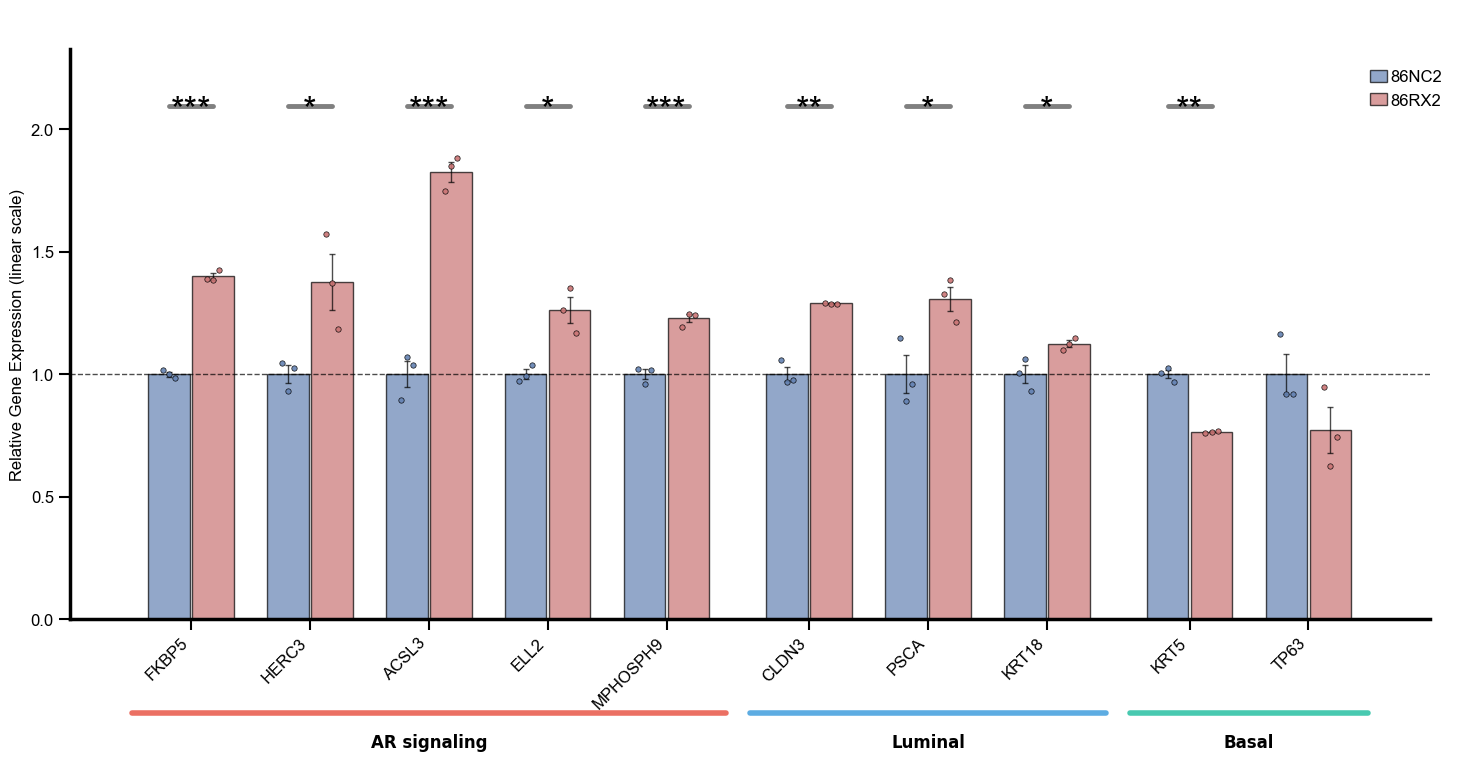

Visualizations complete. Plots saved in: /Users/catherinezhang/Desktop/Mu_Lab/qPCR_final_ver1/86_siRNA_comb


In [6]:
if __name__ == "__main__":
    # After running the main processing pipeline:
    nc = "86NC2"
    processed_df, error_df, individual_df = process_qpcr_data_with_errors(input_path, output_file=output_file, neg_control=nc)
    
    visualize_qpcr_data_with_errors(
        processed_df, 
        error_df, 
        individual_df,  
        output_folder=f"{plot_output_path}",
        reorder_cols="01",
        num_cols_to_reorder=2,
        subplot_height_ratios=(1, 3),  # Top=25%, Bottom=75% 
        show_significance=True,  
        neg_control_sample=nc  
        # subplot_height_ratios=(1, 2)  # Top=33%, Bottom=67%
        # subplot_height_ratios=(2, 3)  # Top=40%, Bottom=60%
        # subplot_height_ratios=(1, 4)  # Top=20%, Bottom=80%
        # show_significance=False 
    )